<div align="center">
  <img src="pageHeaderLogoImage_es_ES.png" width="300"/>
  
  <h1>Universidad de Guadalajara</h1>
  <h2>Centro Universitario de Guadalajara</h2>
  
  <br>
  
  <h2>Proyecto Final</h2>
  <h3>Predicción de Enfermedad Cardíaca mediante Técnicas de Machine Learning</h3>
  
  <br>
  
  <h3>Introducción a la IA: Machine Learning<br>Procesamiento de Datos</h3>
  
  <br>
  
  <table>
    <tr><td><b>Alumno:</b></td><td>Martin Angel Carrizalez Piña</td></tr>
    <tr><td><b>Profesor:</b></td><td>Juan Carlos López</td></tr>
    <tr><td><b>Fecha de entrega:</b></td><td>18 de mayo de 2026</td></tr>
    <tr><td><b>Dataset:</b></td><td>Janosi et al. (1989). Heart Disease. UCI Machine Learning Repository.<br>https://doi.org/10.24432/C52P4X</td></tr>
  </table>
</div>

Carga del Data set y exploración

In [5]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

heart = fetch_ucirepo(id=45)
df = pd.DataFrame(heart.data.features)
df['target'] = heart.data.targets

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [9]:
df['target'].value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [15]:
df['ca'].value_counts()

ca
0.0    176
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

In [16]:
df['thal'].value_counts()


thal
3.0    166
7.0    117
6.0     18
Name: count, dtype: int64

In [10]:
df.notnull().sum()

age         303
sex         303
cp          303
trestbps    303
chol        303
fbs         303
restecg     303
thalach     303
exang       303
oldpeak     303
slope       303
ca          299
thal        301
target      303
dtype: int64

Graficas de exploraciòn

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

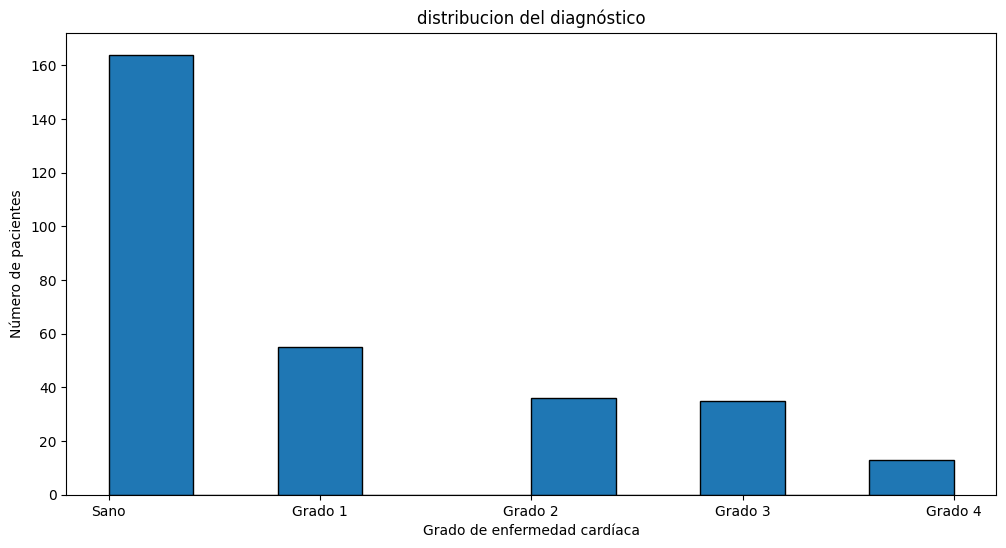

In [13]:
plt.figure(figsize=(12, 6))  
plt.hist(df['target'], bins=10, edgecolor='black')   
plt.title("distribucion del diagnóstico")                
plt.xlabel("Grado de enfermedad cardíaca")         
plt.ylabel("Número de pacientes") 
plt.xticks([0, 1, 2, 3, 4], ['Sano', 'Grado 1', 'Grado 2', 'Grado 3', 'Grado 4'])        
plt.show()                          

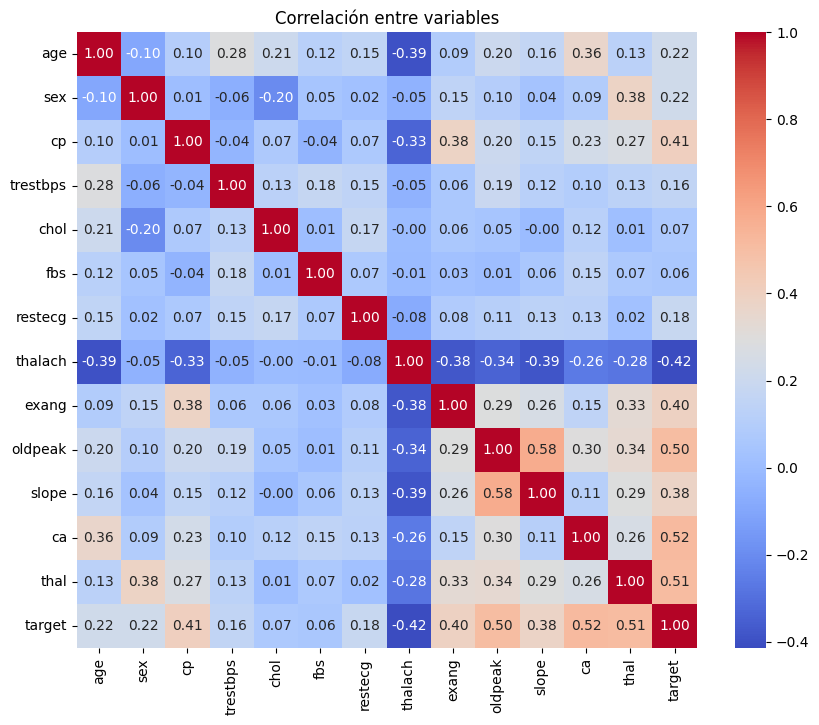

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlación entre variables")
plt.show()

* Limpieza y preprocesamiento

Imputacion de datos faltantes

In [17]:
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

In [18]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Justificaciòn

ca → número de vasos sanguíneos principales coloreados por fluoroscopía (0, 1, 2 o 3). Básicamente cuántas arterias están bloqueadas.

thal → tipo de talasemia del paciente (3 = normal, 6 = defecto fijo, 7 = defecto reversible). Es una condición de la sangre que afecta el corazón.

thal → mediana porque es categórico ordinal

ca → mediana porque es numérico discreto y con pocos valores posibles (0-3), el promedio podría dar 1.67 que no existe en la realidad

* Binarizaciòn de ls variable Objetivo (Diagnostico)

In [21]:
df['target'] = df['target'].apply(lambda x: 1 if x>0 else 0)

In [22]:
df['target'].value_counts()

target
0    164
1    139
Name: count, dtype: int64

* Estandarizaciòn de variables

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
df_estandarizado = df.copy()

In [26]:
estandarizador = StandardScaler()

In [28]:
df_estandarizado[['chol','trestbps','thalach','oldpeak']] = estandarizador.fit_transform(df_estandarizado[['chol','trestbps','thalach','oldpeak']])

In [29]:
df_estandarizado[['chol','trestbps','thalach','oldpeak']].describe()

,chol,trestbps,thalach,oldpeak
count,3.030000e+02,3.030000e+02,3.030000e+02,3.030000e+02
mean,2.345026e-16,4.426236e-16,-1.172513e-16,2.345026e-17
std,1.001654e+00,1.001654e+00,1.001654e+00,1.001654e+00
min,-2.334877e+00,-2.145037e+00,-3.442067e+00,-8.968617e-01
25%,-6.905030e-01,-6.652997e-01,-7.053073e-01,-8.968617e-01
50%,-1.101357e-01,-9.616980e-02,1.485618e-01,-2.067053e-01
75%,5.476139e-01,4.729601e-01,7.178079e-01,4.834512e-01
max,6.138485e+00,3.887739e+00,2.294182e+00,4.451851e+00


## Justificación de estandarización

Se estandarizaron las variables colesterol sérico, presión arterial en reposo, 
frecuencia cardíaca máxima y depresión del segmento ST porque son numéricas 
continuas con muchos valores posibles, lo que puede confundir a los modelos.

No se estandarizaron sexo, glucosa en ayunas y angina por ejercicio porque ya 
son binarias (0 o 1). Tipo de dolor, pendiente ST, electrocardiograma y vasos 
principales no se estandarizaron porque son categóricas con pocos valores posibles. 
La edad es numérica continua pero su rango tiene sentido tal como está.

## Entrenamiento

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X = df.drop(columns=['target'])
y = df['target']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
print(X_train.shape)
print(X_test.shape)

(242, 13)
(61, 13)


In [36]:
X_estandar = df_estandarizado.drop(columns=['target'])
y_estandar = df_estandarizado['target']

In [37]:
X_train_estandar, X_test_estandar, y_train_estandar, y_test_estandar = train_test_split(X_estandar, y_estandar, test_size=0.2, random_state=42)

In [38]:
print(X_train_estandar.shape)
print(X_test_estandar.shape)

(242, 13)
(61, 13)


## MOdelado

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report

Arbol de decisiòn

In [41]:
arbol = DecisionTreeClassifier(random_state=42)
arbol.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
y_pred_arbol = arbol.predict(X_test)
print(accuracy_score(y_test, y_pred_arbol))

0.7540983606557377


In [43]:
print(classification_report(y_test, y_pred_arbol))

              precision    recall  f1-score   support

           0       0.73      0.76      0.75        29
           1       0.77      0.75      0.76        32

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



In [45]:
cv_arbol = cross_val_score(arbol, X, y, cv=5)
print(cv_arbol)
print(cv_arbol.mean())

[0.72131148 0.93442623 0.6557377  0.73333333 0.68333333]
0.7456284153005465


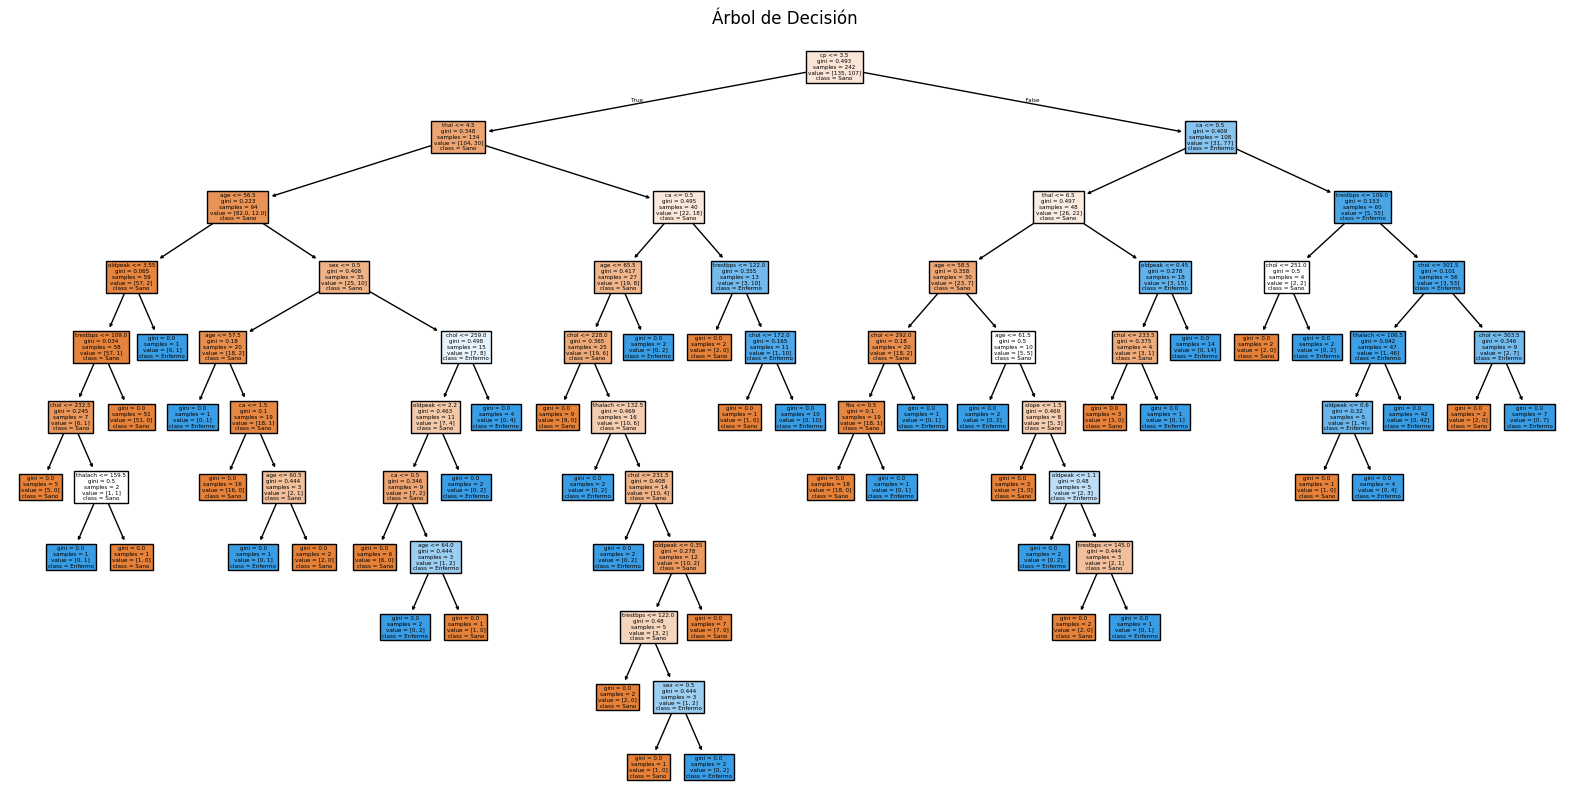

In [48]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(arbol, feature_names=X.columns, class_names=['Sano', 'Enfermo'], filled=True)
plt.title("Árbol de Decisión")
plt.show()

In [49]:
arbol_podado = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol_podado.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


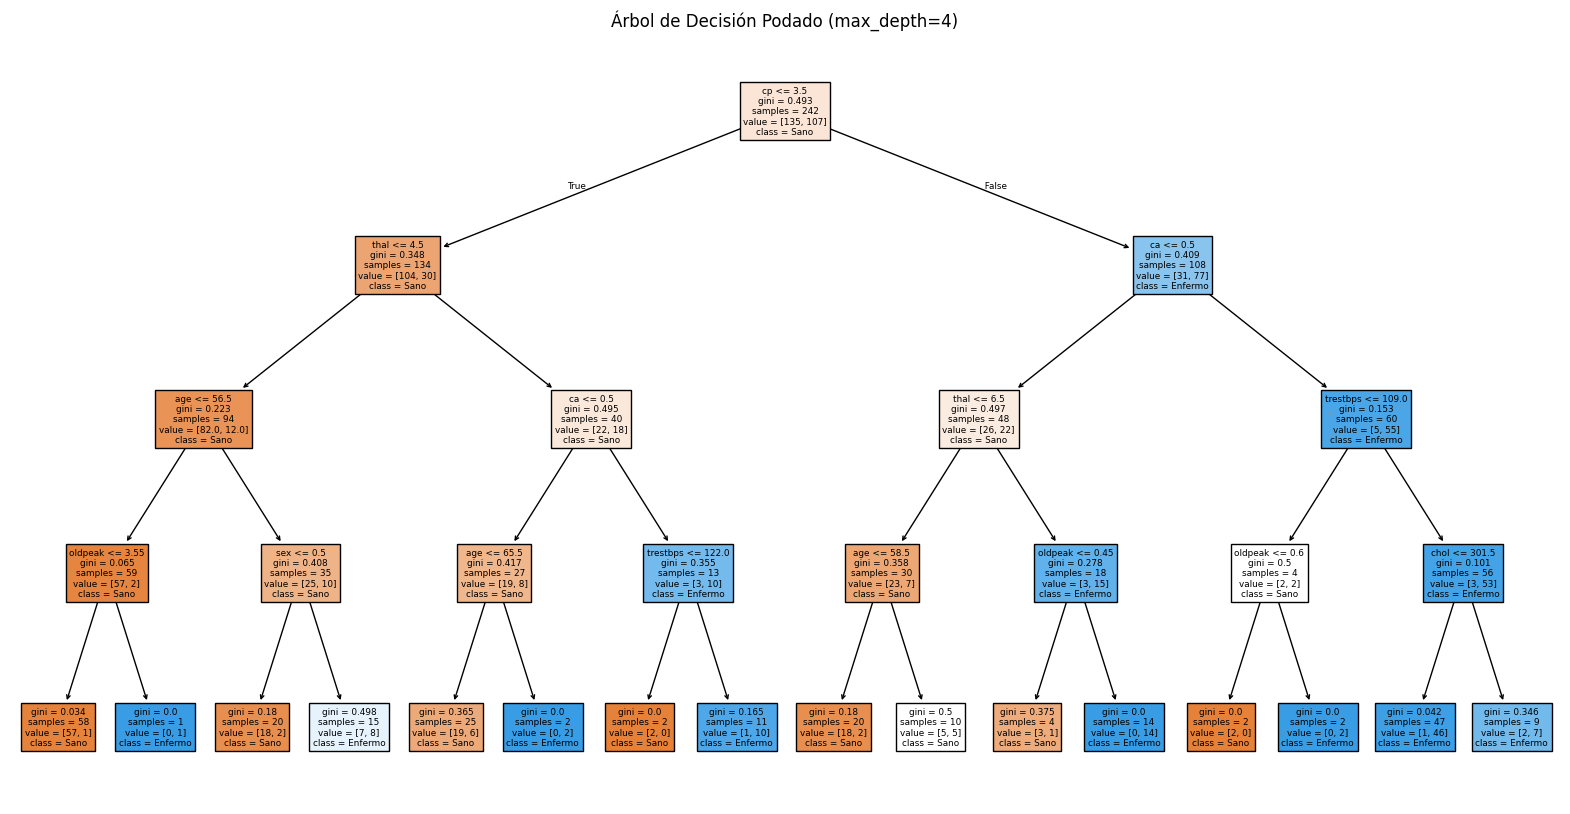

In [50]:
plt.figure(figsize=(20, 10))
plot_tree(arbol_podado, feature_names=X.columns, class_names=['Sano', 'Enfermo'], filled=True)
plt.title("Árbol de Decisión Podado (max_depth=4)")
plt.show()

In [51]:
y_pred_podado = arbol_podado.predict(X_test)
print(accuracy_score(y_test, y_pred_podado))
print(classification_report(y_test, y_pred_podado))

0.7213114754098361
              precision    recall  f1-score   support

           0       0.67      0.83      0.74        29
           1       0.80      0.62      0.70        32

    accuracy                           0.72        61
   macro avg       0.73      0.73      0.72        61
weighted avg       0.74      0.72      0.72        61



# SVM

In [52]:
from sklearn.svm import SVC

In [86]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_estandar, y_train_estandar)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [87]:
y_pred_svm = SVM.predict(X_test_estandar)
print(accuracy_score(y_test_estandar, y_pred_svm))
print(classification_report(y_test_estandar, y_pred_svm))

0.8688524590163934
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [88]:
cv_svm = cross_val_score(SVM, X_estandar, y_estandar, cv=5)
print(cv_svm)
print(cv_svm.mean())

[0.85245902 0.85245902 0.7704918  0.81666667 0.76666667]
0.8117486338797815


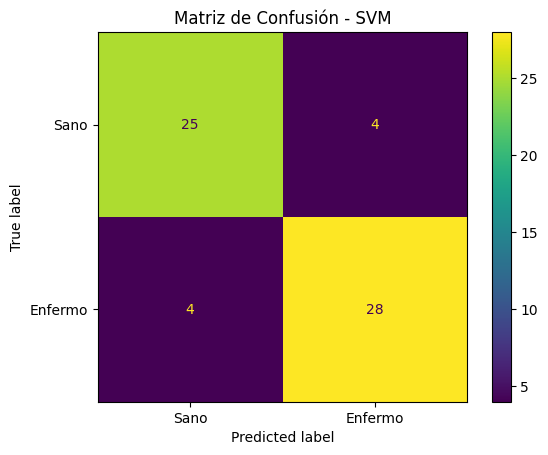

In [90]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test_estandar, y_pred_svm, 
                                         display_labels=['Sano', 'Enfermo'])
plt.title("Matriz de Confusión - SVM")
plt.show()

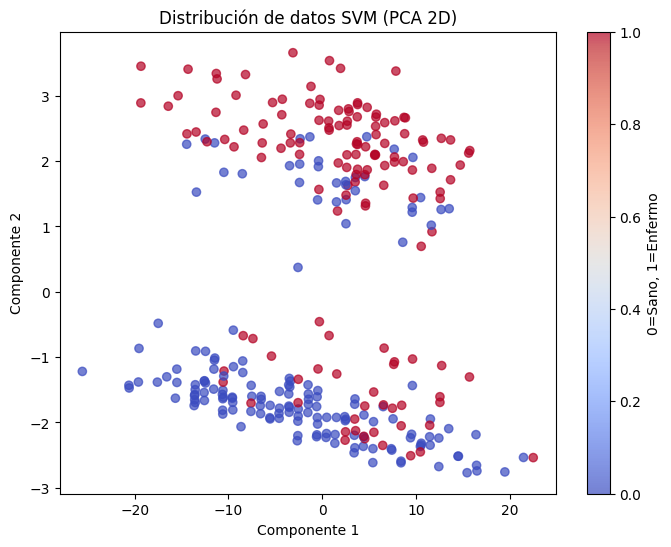

In [91]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_estandar)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_estandar, cmap='coolwarm', alpha=0.7)
plt.title("Distribución de datos SVM (PCA 2D)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.colorbar(label="0=Sano, 1=Enfermo")
plt.show()

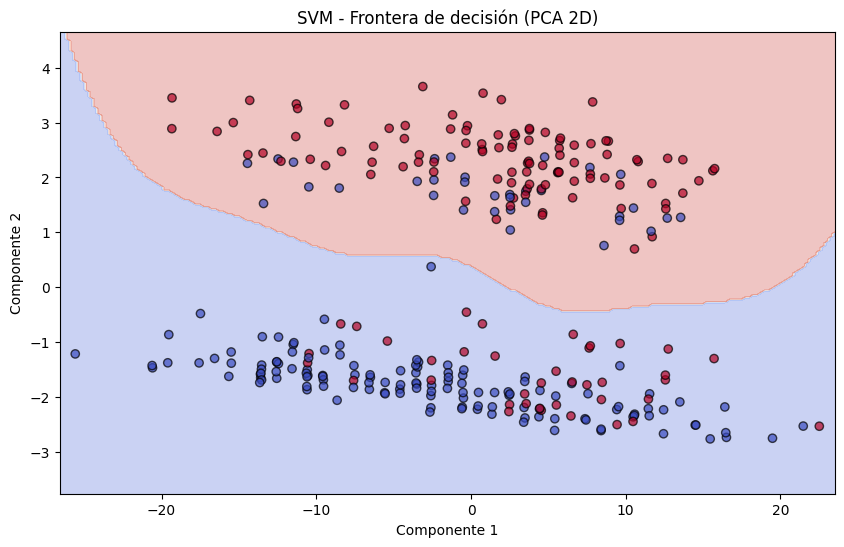

In [92]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import numpy as np

# Reducir a 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_estandar)

# Entrenar SVM sobre los 2 componentes
svm_pca = SVC(kernel='rbf', random_state=42)
svm_pca.fit(X_pca, y_estandar)

# Crear malla de puntos
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predicción sobre la malla
Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_estandar, cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.title("SVM - Frontera de decisión (PCA 2D)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

# Red Neuronal

In [63]:
from sklearn.neural_network import MLPClassifier

In [66]:
red = MLPClassifier(max_iter=1000, random_state=42)
red.fit(X_train_estandar, y_train_estandar)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [67]:
y_pred_red = red.predict(X_test_estandar)
print(accuracy_score(y_test_estandar, y_pred_red))
print(classification_report(y_test_estandar, y_pred_red))

0.8524590163934426
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [69]:
cv_red = cross_val_score(red, X_estandar, y_estandar, cv=5)
print(cv_red)
print(cv_red.mean())

[0.85245902 0.85245902 0.7704918  0.81666667 0.76666667]
0.8117486338797815


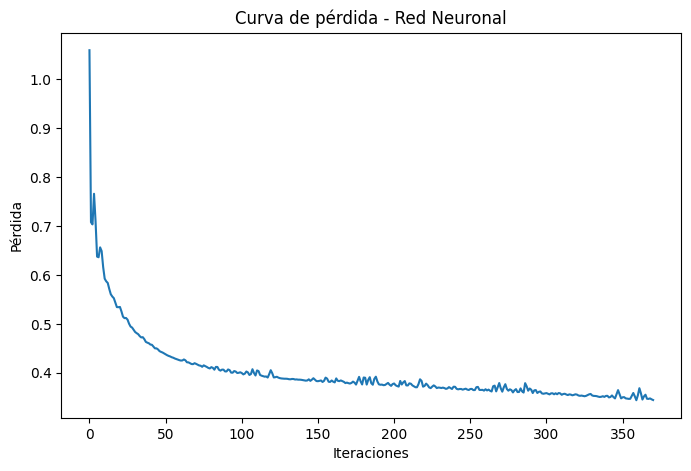

In [70]:
plt.figure(figsize=(8, 5))
plt.plot(red.loss_curve_)
plt.title("Curva de pérdida - Red Neuronal")
plt.xlabel("Iteraciones")
plt.ylabel("Pérdida")
plt.show()

# K-MEANS

In [71]:
from sklearn.cluster import KMeans

In [72]:
KM=KMeans(n_clusters=2, random_state=42)
KM.fit(X_estandar)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [74]:
clusters = KM.labels_
print(pd.crosstab(clusters, y_estandar, rownames=['Cluster'], colnames=['Real']))

Real      0    1
Cluster         
0        83   36
1        81  103


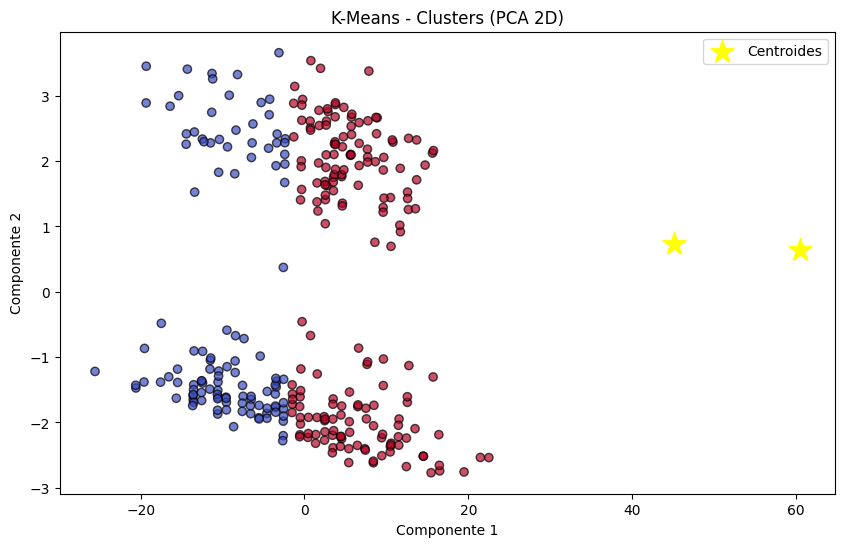

In [75]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.scatter(KM.cluster_centers_[:, 0], KM.cluster_centers_[:, 1], 
            c='yellow', marker='*', s=300, label='Centroides')
plt.title("K-Means - Clusters (PCA 2D)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.show()

c:\Users\angel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


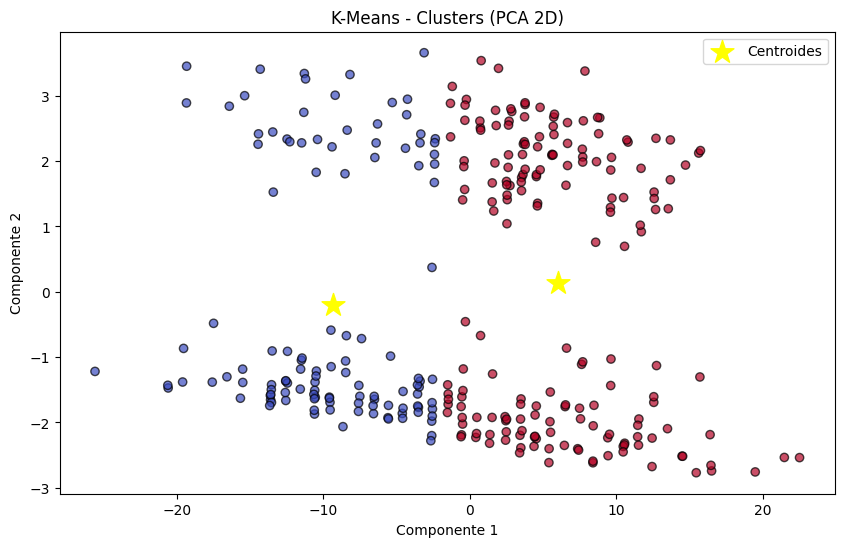

In [76]:
centroides_pca = pca.transform(KM.cluster_centers_)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], 
            c='yellow', marker='*', s=300, label='Centroides')
plt.title("K-Means - Clusters (PCA 2D)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.show()

In [77]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
import shap

c:\Users\angel\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


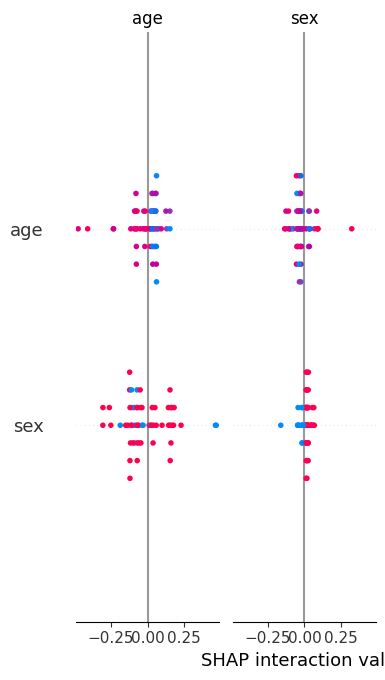

In [80]:
explicador_arbol = shap.TreeExplainer(arbol)
shap_values_arbol = explicador_arbol.shap_values(X_test)

shap.summary_plot(shap_values_arbol, X_test, feature_names=X.columns)

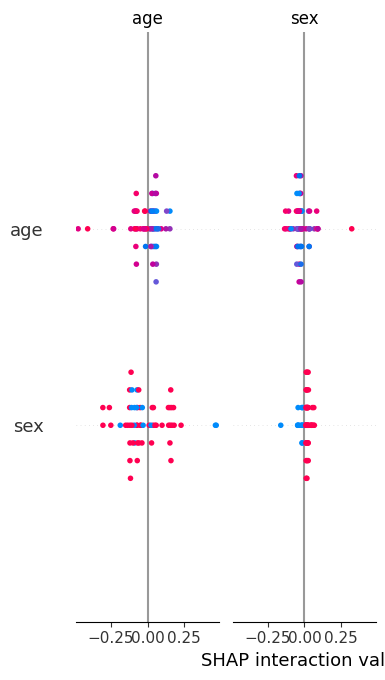

In [81]:
shap.summary_plot(shap_values_arbol, X_test, feature_names=X.columns, plot_type="bar")

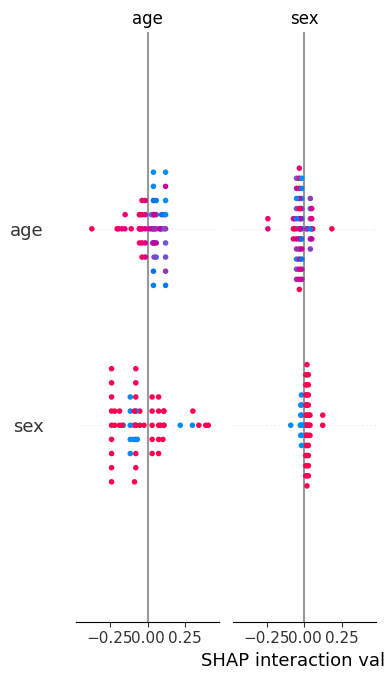

In [82]:
explicador_arbol = shap.TreeExplainer(arbol_podado)
shap_values_arbol = explicador_arbol.shap_values(X_test)

shap.summary_plot(shap_values_arbol, X_test, feature_names=X.columns, plot_type="bar")

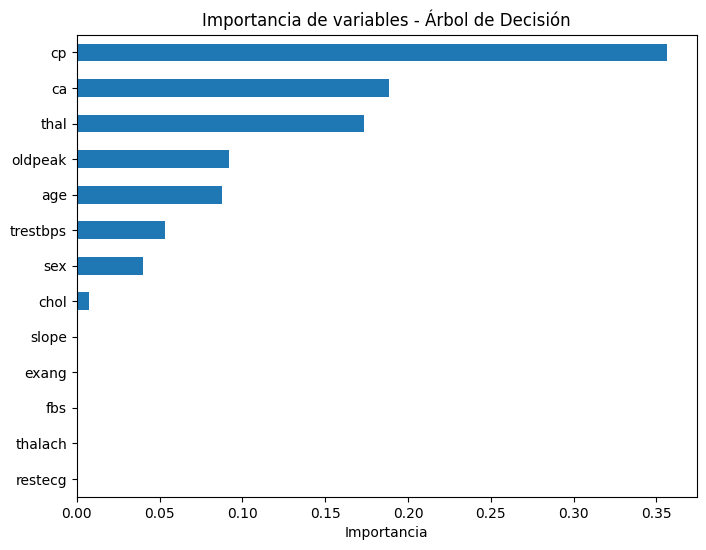

In [83]:
importancias = pd.Series(arbol_podado.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importancias.plot(kind='barh')
plt.title("Importancia de variables - Árbol de Decisión")
plt.xlabel("Importancia")
plt.show()

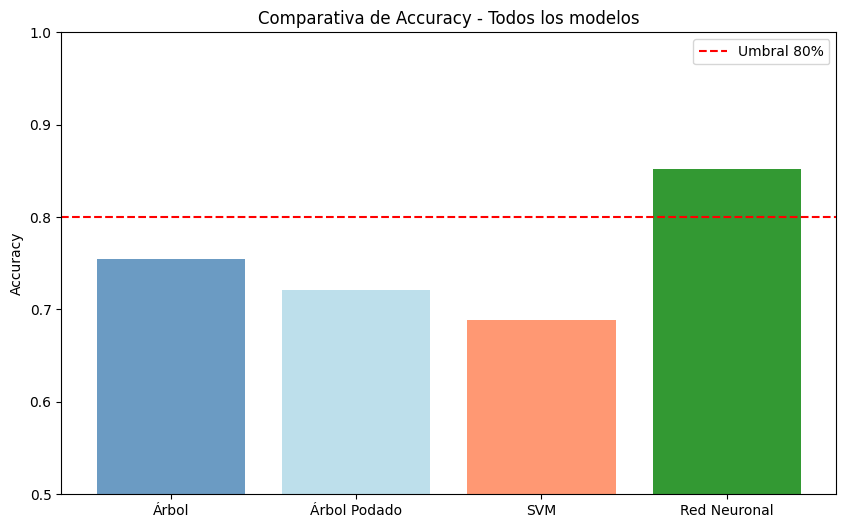

In [85]:
modelos = ['Árbol', 'Árbol Podado', 'SVM', 'Red Neuronal']
accuracies = [
    accuracy_score(y_test, y_pred_arbol),
    accuracy_score(y_test, y_pred_podado),
    accuracy_score(y_test_estandar, y_pred_svm),
    accuracy_score(y_test_estandar, y_pred_red)
]
cv_scores = [cv_arbol.mean(), None, cv_svm.mean(), cv_red.mean()]

plt.figure(figsize=(10, 6))
plt.bar(modelos, accuracies, color=['steelblue', 'lightblue', 'coral', 'green'], alpha=0.8)
plt.title("Comparativa de Accuracy - Todos los modelos")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)
plt.axhline(y=0.8, color='red', linestyle='--', label='Umbral 80%')
plt.legend()
plt.show()

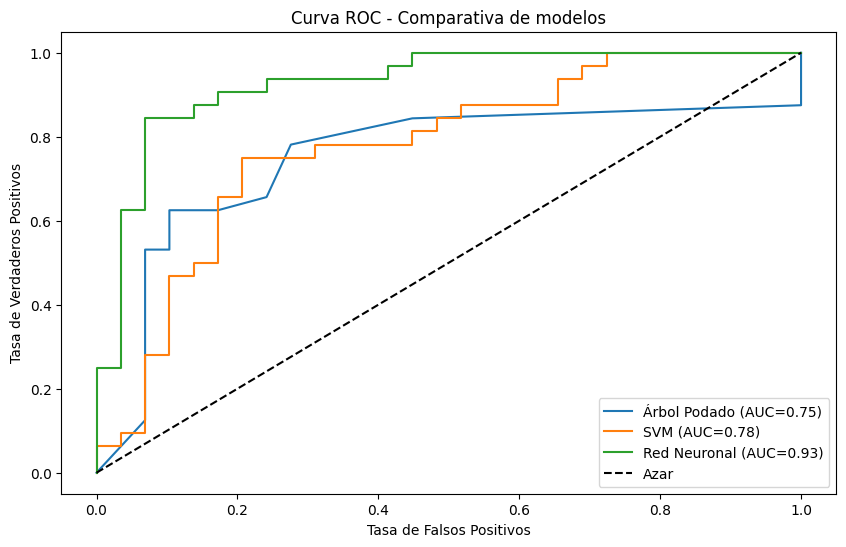

In [93]:
from sklearn.metrics import roc_curve, auc

# Probabilidades de cada modelo
prob_arbol = arbol_podado.predict_proba(X_test)[:, 1]
prob_svm = svm.predict_proba(X_test_estandar)[:, 1]
prob_red = red.predict_proba(X_test_estandar)[:, 1]

# Curvas ROC
fpr_arbol, tpr_arbol, _ = roc_curve(y_test, prob_arbol)
fpr_svm, tpr_svm, _ = roc_curve(y_test_estandar, prob_svm)
fpr_red, tpr_red, _ = roc_curve(y_test_estandar, prob_red)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(fpr_arbol, tpr_arbol, label=f'Árbol Podado (AUC={auc(fpr_arbol, tpr_arbol):.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC={auc(fpr_svm, tpr_svm):.2f})')
plt.plot(fpr_red, tpr_red, label=f'Red Neuronal (AUC={auc(fpr_red, tpr_red):.2f})')
plt.plot([0,1],[0,1], 'k--', label='Azar')
plt.title("Curva ROC - Comparativa de modelos")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.legend()
plt.show()

In [95]:
print((y_test.values == y_test_estandar.values).all())

True


# Conclusiòn

Se trabajó sobre el dataset UCI Heart Disease Cleveland con el objetivo de identificar pacientes con enfermedad cardíaca mediante técnicas de Machine Learning. Se exploraron las 13 variables clínicas, se identificó la variable objetivo (target) y se binarizó para distinguir entre pacientes sanos y enfermos. Durante el preprocesamiento se imputaron 6 valores faltantes en las variables ca y thal usando la mediana, y se estandarizaron 4 variables numéricas continuas (chol, trestbps, thalach y oldpeak) para los modelos SVM, Red Neuronal y K-Means.

Las variables más importantes para la predicción fueron el tipo de dolor de pecho (cp), los vasos principales coloreados por fluoroscopía (ca), la talasemia (thal) y la depresión del segmento ST (oldpeak), lo cual tiene coherencia clínica con los indicadores de riesgo cardiovascular.

Se entrenaron y evaluaron cuatro modelos. La Red Neuronal obtuvo el mejor desempeño con un AUC de 0.93 y un accuracy de 85%, siendo el modelo más recomendable para un contexto médico donde detectar enfermos no detectados tiene mayor costo que una falsa alarma. El SVM obtuvo el mayor accuracy puntual con 87% tras activar la calibración de probabilidades.
Como limitación principal, el dataset cuenta con solo 303 pacientes de una sola institución y datos de 1989, lo que limita la generalización del modelo. Como trabajo futuro se podría incorporar datasets más amplios y validación clínica real.

# Ensamble

In [96]:
from sklearn.ensemble import VotingClassifier

In [99]:
ensamble = VotingClassifier(estimators=[
    ('svm', svm),
    ('red', red)
], voting='soft')

In [100]:
ensamble = ensamble.fit(X_train_estandar, y_train_estandar)
y_pred_ensamble = ensamble.predict(X_test_estandar)
print(accuracy_score(y_test_estandar, y_pred_ensamble))

0.8524590163934426


# guardar modleos para dasboard

In [102]:
import joblib

joblib.dump(arbol_podado, 'modelo_arbol.pkl')
joblib.dump(svm, 'modelo_svm.pkl')
joblib.dump(red, 'modelo_red.pkl')
joblib.dump(KM, 'modelo_kmeans.pkl')
joblib.dump(estandarizador, 'estandarizador.pkl')
joblib.dump(X_test, 'X_test.pkl')
joblib.dump(X_test_estandar, 'X_test_scaled.pkl')
joblib.dump(y_test, 'y_test.pkl')

['y_test.pkl']

In [104]:
resultados = {
    'Árbol Podado': accuracy_score(y_test, y_pred_podado),
    'SVM': accuracy_score(y_test_estandar, y_pred_svm),
    'Red Neuronal': accuracy_score(y_test_estandar, y_pred_red)
}
joblib.dump(resultados, 'resultados.pkl')

['resultados.pkl']